# Analysis of experiment #7: B&P

## Read data

In [44]:
# Read csv

import pandas as pd
import numpy as np

df = pd.read_csv("stats7.csv")

# Add column with edge probability
df["p"] = df.instance.apply(lambda s: float(s.split("_")[2][1:]))

# Distinguish instances solved by optimality in the root node
df.loc[(df.nodes == 1) & (df.state == "OPTIMAL"), "state"] = "OPTIMAL IN ROOT"

# Join MWISS time
df['rootTimeMwis'] = df['rootTimeMwis1'] + df['rootTimeMwis2']
df['otherNodesTimeMwis'] = df['otherNodesTimeMwis1'] + df['otherNodesTimeMwis2']

# Join MWISS columns
df['rootNColsMwis'] = df['rootNColsMwis1'] + df['rootNColsMwis2']
df['otherNodesNColsMwis'] = df['otherNodesNColsMwis1'] + df['otherNodesNColsMwis2']

# Absolute gap
df['absGap'] = df.apply(lambda row: row.ub - row.lb if row.gap != -1 else -1, axis=1)
df['absGapRoot'] = df.apply(lambda row: row.rootub - row.rootlb if row.rootub > 0 else -1, axis=1)

In [45]:
df.columns

Index(['instance', 'solver', 'run', 'nvertices', 'nedges', 'nP', 'nQ', 'nvars',
       'ncons', 'state', 'terminationReason', 'time', 'nodes', 'nodesLeft',
       'lb', 'ub', 'gap', 'nNodesInt', 'nNodesFrac', 'nNodesGcp',
       'nNodesTrivial', 'nNodesInfeas', 'nNodesInfeasPrepro',
       'nNodesInfeasCheck', 'nNodesInfeasAux', 'gcpAvgTime', 'nsol',
       'nsolHeur', 'nsolLR', 'nsolGCP', 'nsolTrivial', 'ninitSol',
       'ninitDummy', 'ninit', 'rootlb', 'rootub', 'rootHeurTime',
       'rootFeasTime', 'rootNCalls', 'rootNCallsPool', 'rootNCallsHeur',
       'rootNCallsMwis1', 'rootNCallsMwis2', 'rootNCallsExact', 'rootNCols',
       'rootNColsPool', 'rootNColsHeur', 'rootNColsMwis1', 'rootNColsMwis2',
       'rootNColsExact', 'rootTime', 'rootTimePool', 'rootTimeHeur',
       'rootTimeMwis1', 'rootTimeMwis2', 'rootTimeExact', 'otherNodesHeurTime',
       'otherNodesFeasNCalls', 'otherNodesFeasTime', 'otherNodesNCalls',
       'otherNodesNCallsPool', 'otherNodesNCallsHeur', 'otherNode

## Summary

<Axes: >

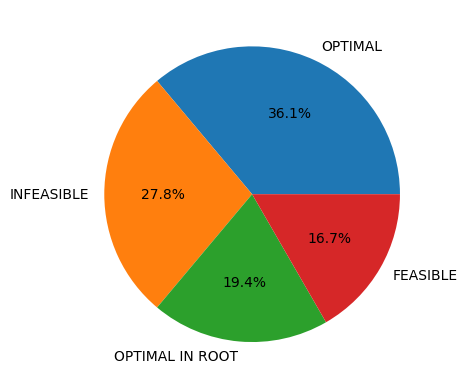

In [46]:
df.state.value_counts().plot.pie(autopct='%1.1f%%')

## Infeasible instances

In [47]:
df_inf = df[df.state == "INFEASIBLE"]
df_inf = df_inf.sort_values(['nvertices', 'p', 'nP', 'nQ']).reset_index(drop=True)

In [48]:
df_inf2 = df_inf[['nvertices', 'p', 'nP', 'nQ', 'state', 'nodes', 'nNodesFrac', 'nNodesInt', 'nNodesGcp', 'nNodesTrivial', 'nNodesInfeas',
           'time', 'nNodesInfeas', 'nNodesInfeasPrepro', 'nNodesInfeasCheck', 'nNodesInfeasAux']]
columns = [('N','',''), ('p','',''), ('n','',''), ('m','',''), ('status','',''), ('nodes','total',''), ('nodes','frac',''), 
           ('nodes','int',''), ('nodes','gcp',''), ('nodes','trivial',''), ('nodes','infeas',''), 
           ('time (s)','',''), ('infeasible nodes','total',''), ('infeasible nodes','prepro',''), ('infeasible nodes','check',''), ('infeasible nodes','aux','')]
df_inf2.columns = pd.MultiIndex.from_tuples(columns)
df_inf2[('nodes','infeas','')] = df_inf2[('nodes','infeas','')].round(0).astype(int)
df_inf2[('infeasible nodes','total','')] = df_inf2[('infeasible nodes','total','')].round(0).astype(int)
df_inf2

N     p   n   m      status nodes                              time (s)  \
                                 total frac int gcp trivial infeas             
                                                                               
0   90  0.25  36  27  INFEASIBLE     1    0   0   0       0      1  0.000269   
1   90  0.25  36  36  INFEASIBLE     1    0   0   0       0      1  0.000261   
2  100  0.50  40  30  INFEASIBLE     1    0   0   0       0      1  0.000728   
3  100  0.50  40  40  INFEASIBLE     1    0   0   0       0      1  0.000645   
4  110  0.75  33  44  INFEASIBLE     1    0   0   0       0      1  0.001026   
5  110  0.75  44  33  INFEASIBLE     1    0   0   0       0      1  0.001479   
6  110  0.75  44  33  INFEASIBLE     1    0   0   0       0      1  0.002031   
7  110  0.75  44  33  INFEASIBLE     1    0   0   0       0      1  0.001911   
8  110  0.75  44  44  INFEASIBLE     1    0   0   0       0      1  0.001260   
9  110  0.75  44  44  INFEASIBLE     1    0   0   0       0      1  0.001895   

  infeasible nodes                   
             total prepro check aux  
                                     
0                1      1     0   0  
1                1      1     0   0  
2                1      1     0   0  
3                1      1     0   0  
4                1      1     0   0  
5                1      1     0   0  
6                1      1     0   0  
7                1      1     0   0  
8                1      1     0   0  
9                1      1     0   0

## Optimal in root instances

In [53]:
df_root = df[df.state == "OPTIMAL IN ROOT"]
df_root = df_root.sort_values(['nvertices', 'p', 'nP', 'nQ']).reset_index(drop=True)

In [54]:
df_root2 = df_root[['nvertices', 'p', 'nP', 'nQ', 'state', 'nodes', 'nNodesFrac', 'nNodesInt', 'nNodesGcp', 'nNodesTrivial', 'nNodesInfeas',
           'time', 'rootlb', 'rootub', 'absGapRoot']]
columns = [('N','',''), ('p','',''), ('n','',''), ('m','',''), ('status','',''), ('nodes','total',''), ('nodes','frac',''), 
           ('nodes','int',''), ('nodes','gcp',''), ('nodes','trivial',''), ('nodes','infeas',''), ('time (s)','',''), 
           ('root gap','lb',''), ('root gap','ub',''), ('root gap','diff','')]
df_root2.columns = pd.MultiIndex.from_tuples(columns)
df_root2[('nodes','infeas','')] = df_root2[('nodes','infeas','')].round(0).astype(int)
df_root2[('time (s)','','')] = df_root2[('time (s)','','')].round(0).astype(int)
df_root2[('root gap','ub','')] = df_root2[('root gap','ub','')].round(0).astype(int)
df_root2 = df_root2.round({('root gap','lb',''): 1, ('root gap','diff',''): 1})
df_root2

N     p   n   m           status nodes                              \
                                     total frac int gcp trivial infeas   
                                                                         
0  90  0.25  27  27  OPTIMAL IN ROOT     1    1   0   0       0      0   
1  90  0.25  27  27  OPTIMAL IN ROOT     1    1   0   0       0      0   
2  90  0.25  27  27  OPTIMAL IN ROOT     1    1   0   0       0      0   
3  90  0.25  27  36  OPTIMAL IN ROOT     1    1   0   0       0      0   
4  90  0.25  27  36  OPTIMAL IN ROOT     1    1   0   0       0      0   
5  90  0.25  27  36  OPTIMAL IN ROOT     1    1   0   0       0      0   
6  90  0.25  36  36  OPTIMAL IN ROOT     1    1   0   0       0      0   

  time (s) root gap          
                 lb ub diff  
                             
0        9      2.5  3  0.5  
1       24      2.3  3  0.7  
2        8      2.5  3  0.5  
3       17      2.1  3  0.9  
4       16      2.2  3  0.8  
5        9      2.3  3  0.7  
6       25      3.1  4  0.9

## Optimal or feasible instances

In [57]:
df2 = df[(df.state == "OPTIMAL") | (df.state == "FEASIBLE")]
df2 = df2.sort_values(['nvertices', 'p', 'nP', 'nQ']).reset_index(drop=True)

In [59]:
df3 = df2[['nvertices', 'p', 'nP', 'nQ', 'state', 'nodes', 'nNodesFrac', 'nNodesInt', 'nNodesGcp', 'nNodesTrivial', 'nNodesInfeas',
           'time', 'lb', 'ub', 'absGap', 'rootlb', 'rootub', 'absGapRoot']]
columns = [('N','',''), ('p','',''), ('n','',''), ('m','',''), ('status','',''), ('nodes','total',''), ('nodes','frac',''), 
           ('nodes','int',''), ('nodes','gcp',''), ('nodes','trivial',''), ('nodes','infeas',''), ('time (s)','',''), 
           ('gap','lb',''), ('gap','ub',''), ('gap','diff',''), ('root gap','lb',''), ('root gap','ub',''), ('root gap','diff','')]
df3.columns = pd.MultiIndex.from_tuples(columns)
df3[('nodes','infeas','')] = df3[('nodes','infeas','')].round(0).astype(int)
df3[('time (s)','','')] = df3[('time (s)','','')].round(0).astype(int)
df3[('gap','ub','')] = df3[('gap','ub','')].round(0).astype(int)
df3[('root gap','ub','')] = df3[('root gap','ub','')].round(0).astype(int)
df3 = df3.round({('gap','lb',''): 1, ('gap','diff',''): 1, ('root gap','lb',''): 1, ('root gap','diff',''): 1})
df3

N     p   n   m    status nodes                              time (s)  \
                                total  frac int gcp trivial infeas            
                                                                              
0    90  0.25  36  27  FEASIBLE   976   976   0   0       0      0     7200   
1    90  0.25  36  27  FEASIBLE   876   876   0   0       0      0     7200   
2    90  0.25  36  36  FEASIBLE  1472  1472   0   0       0      0     7200   
3   100  0.50  30  30   OPTIMAL  1813  1812   1   0       0      0     5633   
4   100  0.50  30  30   OPTIMAL  1997  1996   1   0       0      0     3936   
5   100  0.50  30  30  FEASIBLE  2358  2358   0   0       0      0     7200   
6   100  0.50  30  40   OPTIMAL   973   973   0   0       0      0     1798   
7   100  0.50  30  40   OPTIMAL  1847  1846   1   0       0      0     2881   
8   100  0.50  30  40  FEASIBLE  2890  2890   0   0       0      0     7200   
9   100  0.50  40  30   OPTIMAL    53    52   1   0       0      0      231   
10  100  0.50  40  30   OPTIMAL   113   112   1   0       0      0      497   
11  100  0.50  40  40  FEASIBLE  1732  1732   0   0       0      0     7200   
12  100  0.50  40  40   OPTIMAL  2389  2388   1   0       0      0     5912   
13  110  0.75  33  33   OPTIMAL   273   272   1   0       0      0      604   
14  110  0.75  33  33   OPTIMAL  1885  1884   1   0       0      0     3741   
15  110  0.75  33  33   OPTIMAL  2489  2487   1   0       0      1     3789   
16  110  0.75  33  44   OPTIMAL  1791  1791   0   0       0      0     2507   
17  110  0.75  33  44   OPTIMAL  1085  1084   1   0       0      0     2440   
18  110  0.75  44  44   OPTIMAL    27    27   0   0       0      0      165   

     gap          root gap           
      lb  ub diff       lb  ub diff  
                                     
0    4.0   5  1.0      3.2   5  1.8  
1    4.0   5  1.0      3.3   5  1.7  
2    4.0   5  1.0      3.1   5  1.9  
3    5.0   5  0.0      4.2   6  1.8  
4    5.0   5  0.0      4.4   7  2.6  
5    5.0   6  1.0      4.2   6  1.8  
6    5.0   5  0.0      4.2   6  1.8  
7    5.0   5  0.0      4.3   6  1.7  
8    5.0   6  1.0      4.1   6  1.9  
9    8.0   8  0.0      7.2  10  2.8  
10   8.0   8  0.0      7.0   9  2.0  
11   7.1   9  1.9      6.3   9  2.7  
12   7.0   7  0.0      6.1   9  2.9  
13   9.0   9  0.0      8.2  10  1.8  
14   9.0   9  0.0      8.0  10  2.0  
15   9.0   9  0.0      8.0  10  2.0  
16   9.0   9  0.0      8.0  10  2.0  
17   8.0   8  0.0      7.3   9  1.7  
18  13.0  13  0.0     11.8  13  1.2

In [61]:
df3 = df2[['nvertices', 'p', 'nP', 'nQ', 'state', 'nodes', 'time',
           'rootTime', 'rootTimeHeur', 'rootTimeMwis', 'rootTimeExact', 
           'otherNodesTime', 'otherNodesTimeHeur', 'otherNodesTimeMwis', 'otherNodesTimeExact',
           'rootNCols', 'rootNColsPool', 'rootNColsHeur', 'rootNColsMwis', 'rootNColsExact',
           'otherNodesNCols', 'otherNodesNColsPool', 'otherNodesNColsHeur', 'otherNodesNColsMwis', 'otherNodesNColsExact']]
columns = [('N','',''), ('p','',''), ('n','',''), ('m','',''), ('status','',''), ('nodes','total',''), ('time (s)','',''), 
           ('pricing time (s)', 'root', 'total'), ('pricing time (s)', 'root', 'heur'), ('pricing time (s)', 'root', 'MWSS'), ('pricing time (s)', 'root', 'ILP'), 
           ('pricing time (s)', 'avg. non-root node', 'total'), ('pricing time (s)', 'avg. non-root node', 'heur'), ('pricing time (s)', 'avg. non-root node', 'MWSS'), ('pricing time (s)', 'avg. non-root node', 'ILP'),
           ('#pricing columns', 'root', 'total'), ('#pricing columns', 'root', 'pool'), ('#pricing columns', 'root', 'heur'), ('#pricing columns', 'root', 'MWSS'), ('#pricing columns', 'root', 'ILP'),
           ('#pricing columns', 'avg. non-root node', 'total'), ('#pricing columns', 'avg. non-root node', 'pool'), ('#pricing columns', 'avg. non-root node', 'heur'), ('#pricing columns', 'avg. non-root node', 'MWSS'), ('#pricing columns', 'avg. non-root node', 'ILP') ]
df3.columns = pd.MultiIndex.from_tuples(columns)
# df3[('nodes','infeas','')] = df3[('nodes','infeas','')].round(0).astype(int)
df3[('time (s)','','')] = df3[('time (s)','','')].round(0).astype(int)
df3 = df3.round({('gap (%)','',''): 2, ('lb','',''): 2, ('ub','',''): 2, 
                 ('pricing time (s)', 'root', 'total'): 2, ('pricing time (s)', 'root', 'heur'): 2, ('pricing time (s)', 'root', 'MWSS'): 2, ('pricing time (s)', 'root', 'ILP'): 2, 
                 ('pricing time (s)', 'avg. non-root node', 'total'): 1, ('pricing time (s)', 'avg. non-root node', 'heur'): 2, ('pricing time (s)', 'avg. non-root node', 'MWSS'): 2, ('pricing time (s)', 'avg. non-root node', 'ILP'): 1})
pd.set_option('display.max_columns', None)
df3

N     p   n   m    status nodes time (s) pricing time (s)              \
                                total                      root               
                                                          total  heur  MWSS   
0    90  0.25  36  27  FEASIBLE   976     7200            34.07  0.66  0.17   
1    90  0.25  36  27  FEASIBLE   876     7200            34.34  0.51  0.21   
2    90  0.25  36  36  FEASIBLE  1472     7200            15.13  0.46  0.14   
3   100  0.50  30  30   OPTIMAL  1813     5633            19.10  0.30  0.13   
4   100  0.50  30  30   OPTIMAL  1997     3936            11.06  0.19  0.08   
5   100  0.50  30  30  FEASIBLE  2358     7200            10.01  0.32  0.07   
6   100  0.50  30  40   OPTIMAL   973     1798             5.39  0.20  0.06   
7   100  0.50  30  40   OPTIMAL  1847     2881             8.51  0.22  0.07   
8   100  0.50  30  40  FEASIBLE  2890     7200            14.19  0.18  0.09   
9   100  0.50  40  30   OPTIMAL    53      231            20.87  0.69  0.07   
10  100  0.50  40  30   OPTIMAL   113      497            22.99  0.44  0.10   
11  100  0.50  40  40  FEASIBLE  1732     7200            27.15  0.46  0.19   
12  100  0.50  40  40   OPTIMAL  2389     5912            22.20  0.49  0.21   
13  110  0.75  33  33   OPTIMAL   273      604            10.56  0.19  0.17   
14  110  0.75  33  33   OPTIMAL  1885     3741            14.06  0.24  0.21   
15  110  0.75  33  33   OPTIMAL  2489     3789             7.60  0.18  0.15   
16  110  0.75  33  44   OPTIMAL  1791     2507             4.25  0.20  0.17   
17  110  0.75  33  44   OPTIMAL  1085     2440             7.23  0.21  0.16   
18  110  0.75  44  44   OPTIMAL    27      165            11.29  0.21  0.18   

                                              #pricing columns                 \
          avg. non-root node                              root                  
      ILP              total  heur  MWSS  ILP            total pool heur MWSS   
0   33.24                7.3  0.11  0.03  7.2              634    0  554   13   
1   33.62                8.1  0.11  0.04  8.0              581    0  486   30   
2   14.52                4.9  0.09  0.04  4.7              560    0  482   48   
3   18.68                3.1  0.06  0.02  3.0              291    0  236   44   
4   10.80                1.9  0.04  0.02  1.9              273    0  243   21   
5    9.62                3.0  0.05  0.02  3.0              327    0  302   19   
6    5.14                1.8  0.04  0.02  1.8              260    0  238   18   
7    8.23                1.5  0.04  0.02  1.5              247    0  218   23   
8   13.91                2.5  0.04  0.02  2.4              261    0  216   38   
9   20.12                3.6  0.07  0.01  3.5              615    0  484   74   
10  22.45                4.0  0.06  0.02  3.9              531    0  446   36   
11  26.49                4.1  0.06  0.03  4.0              427    0  354   46   
12  21.51                2.4  0.05  0.02  2.4              400    0  284   90   
13  10.21                2.0  0.04  0.05  1.9              232    0  209   18   
14  13.60                1.9  0.04  0.05  1.8              201    0  165   30   
15   7.27                1.5  0.03  0.04  1.4              198    0  178   17   
16   3.88                1.4  0.03  0.04  1.3              207    0  176   29   
17   6.87                2.2  0.04  0.06  2.1              178    0  164   12   
18  10.90                2.8  0.04  0.07  2.7              226    0  180   37   

                                              
       avg. non-root node                     
   ILP              total pool heur MWSS ILP  
0   67                131   61   40    5  23  
1   65                150   67   50    8  24  
2   30                138   61   46   13  16  
3   11                 81   39   28    7   5  
4    9                 68   34   23    5   4  
5    6                 75   37   25    6   5  
6    4                 62   31   19    8   3  
7    6        